# 01 — Exploratory Data Analysis

**Dataset:** Healthcare Provider Fraud Detection Analysis
(Kaggle: `rohitrox/healthcare-provider-fraud-detection-analysis`).
Source: CMS Medicare claims, ~13 months of data (Nov 2008 – Dec 2009).

**Goal of this notebook**
- Understand the four-table schema and the granularity of the fraud label.
- Quantify class imbalance and identify the strongest fraud signals.
- Surface findings that shape the Day 2 feature engineering.

**Key context.** The `PotentialFraud` label lives at the **provider** level,
not the claim level. A claim is "fraudulent" only by association with a
flagged provider. This drives our modelling choice: features must be
aggregated per provider, and the streaming use-case is "score this incoming
claim using the historical profile of its provider".

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", context="notebook")
RAW = "../data/raw"

## 1. Load the four train tables

In [2]:
train = pd.read_csv(f"{RAW}/Train.csv")
bene  = pd.read_csv(f"{RAW}/Train_Beneficiarydata.csv")
inp   = pd.read_csv(f"{RAW}/Train_Inpatientdata.csv")
out   = pd.read_csv(f"{RAW}/Train_Outpatientdata.csv")

for name, df in [("Train (providers)", train), ("Beneficiary", bene),
                 ("Inpatient claims", inp), ("Outpatient claims", out)]:
    print(f"{name:25s}  shape={df.shape}  mem={df.memory_usage(deep=True).sum()/1e6:5.1f} MB")

Train (providers)          shape=(5410, 2)  mem=  0.7 MB
Beneficiary                shape=(138556, 25)  mem= 54.3 MB


Inpatient claims           shape=(40474, 30)  mem= 55.1 MB


Outpatient claims          shape=(517737, 27)  mem=506.9 MB


**Observation.** 5,410 providers, 138k beneficiaries, ~558k claims
(40k inpatient + 518k outpatient). Outpatient claims dominate volume by ~13×.

## 2. Schema and missing values

In [3]:
def missing_summary(df, name):
    miss = df.isna().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    return pd.DataFrame({"table": name, "column": miss.index, "pct_missing": (miss*100).round(1)})

summaries = [
    missing_summary(train, "Train"),
    missing_summary(bene,  "Beneficiary"),
    missing_summary(inp,   "Inpatient"),
    missing_summary(out,   "Outpatient"),
]
miss_all = pd.concat(summaries, ignore_index=True)
miss_all.sort_values("pct_missing", ascending=False).head(15)

,table,column,pct_missing
20,Outpatient,ClmProcedureCode_6,100.0
1,Inpatient,ClmProcedureCode_6,100.0
2,Inpatient,ClmProcedureCode_5,100.0
25,Outpatient,ClmProcedureCode_1,100.0
24,Outpatient,ClmProcedureCode_2,100.0
23,Outpatient,ClmProcedureCode_3,100.0
22,Outpatient,ClmProcedureCode_4,100.0
21,Outpatient,ClmProcedureCode_5,100.0
26,Outpatient,ClmDiagnosisCode_10,99.8
3,Inpatient,ClmProcedureCode_4,99.7


**Observation.** Missing values cluster in two predictable places:
- **ClmProcedureCode_3..6**: most claims involve 0–2 procedures, so the
  trailing slots are empty by design — we will encode these as
  "number of non-null procedure codes" rather than imputing.
- **DOD** (date of death): only ~1% of beneficiaries are deceased in the
  observation window — expected.

No imputation is needed for the modelling task; the gaps are informative.

## Chart 1 — Provider-level class balance

/tmp/ipykernel_1239707/321243400.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette=["#3b82f6", "#ef4444"])


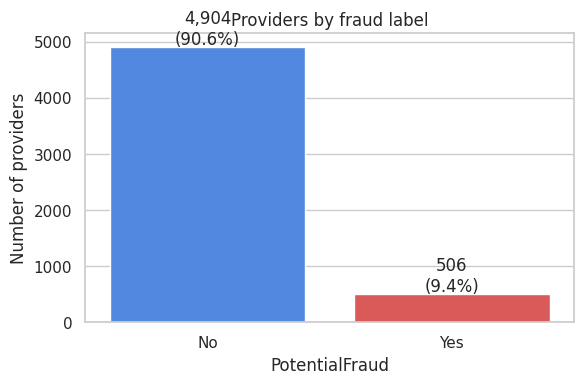

fraud rate (provider level): 0.09353049907578559


In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = train["PotentialFraud"].value_counts()
sns.barplot(x=counts.index, y=counts.values, ax=ax, palette=["#3b82f6", "#ef4444"])
ax.set_title("Providers by fraud label")
ax.set_ylabel("Number of providers")
ax.set_xlabel("PotentialFraud")
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, f"{v:,}\n({v/counts.sum()*100:.1f}%)", ha="center")
plt.tight_layout(); plt.show()

print("fraud rate (provider level):", (train["PotentialFraud"]=="Yes").mean())

**Finding.** 506 of 5,410 providers (~9.35%) are flagged as potentially
fraudulent. This is a moderate class imbalance — not extreme enough to need
SMOTE, but enough to require `scale_pos_weight ≈ 10` in XGBoost and to
report **PR-AUC** and **F1** as primary metrics rather than accuracy.

## Chart 2 — Claims per provider, by fraud label

/tmp/ipykernel_1239707/704451547.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cpp, x="PotentialFraud", y="n_claims", ax=ax,


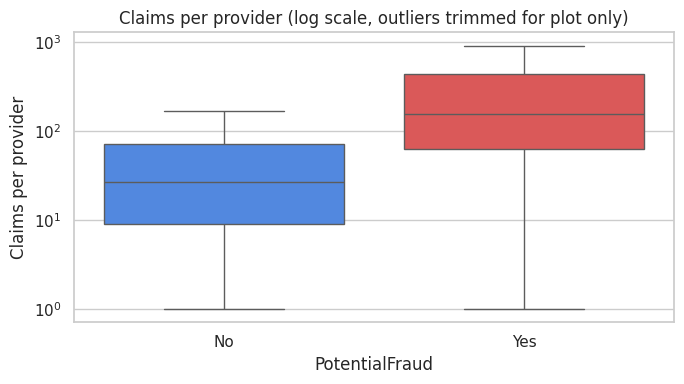

                      mean    50%         std     max
PotentialFraud                                       
No               70.435359   27.0  128.942510  1245.0
Yes             420.545455  155.5  722.734485  8240.0


In [5]:
all_clm = pd.concat([
    inp.merge(train, on="Provider")[["Provider", "PotentialFraud"]],
    out.merge(train, on="Provider")[["Provider", "PotentialFraud"]],
], ignore_index=True)
cpp = all_clm.groupby(["Provider", "PotentialFraud"]).size().reset_index(name="n_claims")

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=cpp, x="PotentialFraud", y="n_claims", ax=ax,
            palette=["#3b82f6", "#ef4444"], showfliers=False)
ax.set_yscale("log")
ax.set_title("Claims per provider (log scale, outliers trimmed for plot only)")
ax.set_ylabel("Claims per provider")
plt.tight_layout(); plt.show()

print(cpp.groupby("PotentialFraud")["n_claims"].describe()[["mean","50%","std","max"]])

**Finding (strong signal).** Fraud-flagged providers file dramatically more
claims — **mean 420 vs 70**, **median 156 vs 27**. The maximum is 8,240
claims by a single fraud provider versus 1,245 for the largest non-fraud
provider. Sheer claim volume per provider is the single most useful
aggregate feature; we will compute it on the Day 2 feature pipeline.

## Chart 3 — Reimbursement amount distribution

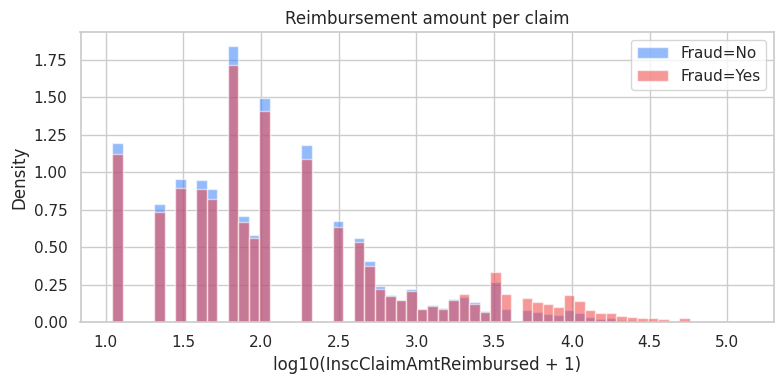

                       mean   50%          std       max
PotentialFraud                                          
No               755.213352  80.0  3056.460166  125000.0
Yes             1389.505066  90.0  4785.074685  125000.0


In [6]:
inp_lbl = inp.merge(train, on="Provider")
out_lbl = out.merge(train, on="Provider")
both    = pd.concat([inp_lbl, out_lbl], ignore_index=True)

fig, ax = plt.subplots(figsize=(8, 4))
for label, color in [("No", "#3b82f6"), ("Yes", "#ef4444")]:
    sub = both[both["PotentialFraud"] == label]["InscClaimAmtReimbursed"]
    sub = sub[sub > 0]
    ax.hist(np.log10(sub + 1), bins=60, alpha=0.55, label=f"Fraud={label}", color=color, density=True)
ax.set_xlabel("log10(InscClaimAmtReimbursed + 1)")
ax.set_ylabel("Density")
ax.set_title("Reimbursement amount per claim")
ax.legend()
plt.tight_layout(); plt.show()

print(both.groupby("PotentialFraud")["InscClaimAmtReimbursed"].describe()[["mean","50%","std","max"]])

**Finding.** Distributions overlap heavily at the low end (most outpatient
claims are < $100), but the right tail is fatter for fraud providers.
**Mean per claim: $1,389 (fraud) vs $755 (non-fraud)** — an 84% lift.
Both populations cap at the dataset maximum of $125,000.

Implication: per-claim amount alone is a weak ranker, but
**aggregate reimbursement per provider** (sum, std, top-percentile) will be
highly discriminative.

## Chart 4 — Inpatient vs outpatient mix

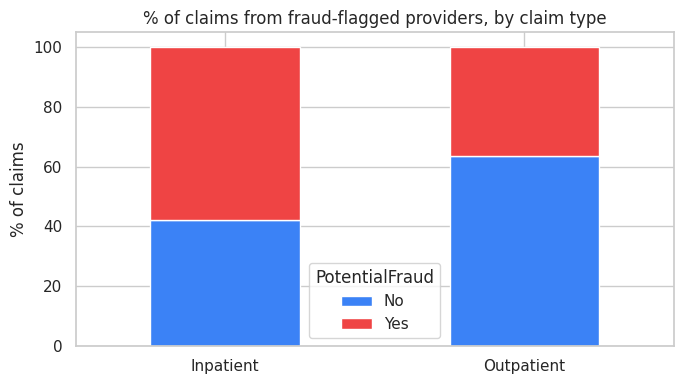

PotentialFraud      No     Yes
Inpatient        17072   23402
Outpatient      328343  189394


In [7]:
mix = pd.DataFrame({
    "Inpatient":  inp_lbl["PotentialFraud"].value_counts(),
    "Outpatient": out_lbl["PotentialFraud"].value_counts(),
}).T
mix_pct = mix.div(mix.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(7, 4))
mix_pct.plot(kind="bar", stacked=True, ax=ax, color=["#3b82f6", "#ef4444"])
ax.set_title("% of claims from fraud-flagged providers, by claim type")
ax.set_ylabel("% of claims")
ax.set_xlabel("")
ax.legend(title="PotentialFraud")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout(); plt.show()

print(mix)

**Finding.** Inpatient claims are *more* likely to come from a flagged
provider (~57%) than outpatient claims (~37%). Inpatient claims also carry
much larger reimbursements, so the inpatient/outpatient flag is a
useful per-claim feature on top of provider-level aggregates.

## Chart 5 — Top 15 primary diagnosis codes

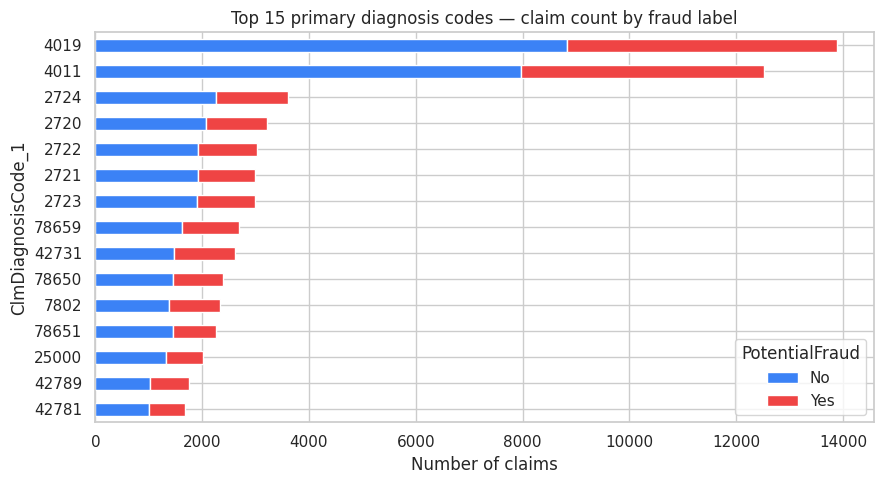

PotentialFraud        No   Yes  fraud_rate
ClmDiagnosisCode_1                        
4019                8823  5063       0.365
4011                7963  4549       0.364
2724                2262  1344       0.373
2720                2070  1140       0.355
2722                1913  1115       0.368
2721                1925  1073       0.358
2723                1910  1085       0.362
78659               1626  1061       0.395
42731               1469  1150       0.439
78650               1449   935       0.392
7802                1370   957       0.411
78651               1453   808       0.357
25000               1313   700       0.348
42789               1025   724       0.414
42781               1000   677       0.404


In [8]:
top_dx = (both.dropna(subset=["ClmDiagnosisCode_1"])
              .groupby(["ClmDiagnosisCode_1", "PotentialFraud"]).size()
              .unstack(fill_value=0))
top_dx["total"] = top_dx.sum(axis=1)
top_dx = top_dx.sort_values("total", ascending=False).head(15)
top_dx["fraud_rate"] = top_dx["Yes"] / top_dx["total"]

fig, ax = plt.subplots(figsize=(9, 5))
top_dx[["No", "Yes"]].plot(kind="barh", stacked=True, ax=ax,
                            color=["#3b82f6", "#ef4444"])
ax.set_title("Top 15 primary diagnosis codes — claim count by fraud label")
ax.set_xlabel("Number of claims")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

print(top_dx[["No", "Yes", "fraud_rate"]].round(3))

**Finding.** The top codes are common chronic-disease diagnoses
(4019/4011 = essential hypertension, 2724 = hyperlipidemia,
42731 = atrial fibrillation, 78659 = chest pain, 78650 = unspecified chest
pain). Fraud rates per top-code vary from ~25% to ~50%, so the
primary-diagnosis code carries meaningful per-claim signal beyond the
provider-level aggregates — high-cardinality, so we'll target-encode it
on Day 2.

## Chart 6 — Fraud rate by State (top 20 by claim volume)

/tmp/ipykernel_1239707/2229763214.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state.index.astype(str), y=state["fraud_rate"], ax=ax,


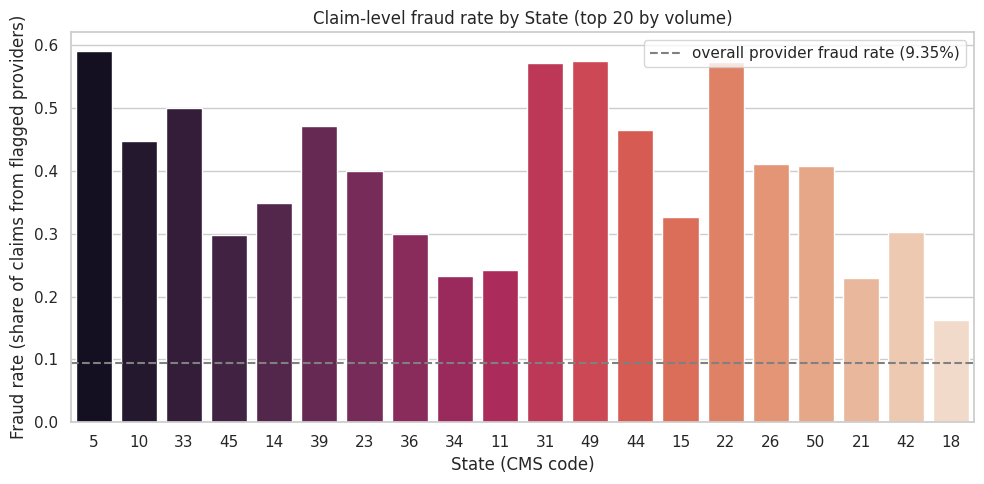

       n_claims  fraud_rate
State                      
5         51350       0.591
10        39073       0.448
33        35024       0.499
45        34022       0.298
14        24417       0.348
39        24251       0.472
23        21343       0.400
36        21291       0.300
34        18905       0.232
11        17003       0.242
31        15940       0.572
49        14997       0.574
44        14418       0.465
15        14213       0.326
22        13624       0.572
26        12911       0.411
50        11740       0.407
21        11261       0.229
42        10491       0.303
18        10322       0.163


In [9]:
bene_clm = both.merge(bene[["BeneID", "State"]], on="BeneID", how="left")
state = (bene_clm.groupby("State")
                 .agg(n_claims=("PotentialFraud", "size"),
                      fraud_rate=("PotentialFraud", lambda s: (s=="Yes").mean()))
                 .sort_values("n_claims", ascending=False).head(20))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=state.index.astype(str), y=state["fraud_rate"], ax=ax,
            palette="rocket")
ax.axhline((train["PotentialFraud"]=="Yes").mean(), ls="--", color="gray",
           label="overall provider fraud rate (9.35%)")
ax.set_title("Claim-level fraud rate by State (top 20 by volume)")
ax.set_xlabel("State (CMS code)")
ax.set_ylabel("Fraud rate (share of claims from flagged providers)")
ax.legend()
plt.tight_layout(); plt.show()

print(state.round(3))

**Finding (strong signal).** Geographic concentration is large: states 5,
33, 31, 22, and 49 show claim-level fraud rates between 50% and 60%,
while others (state 11) sit near 28%. **State** will be a high-value
categorical feature — likely target-encoded.

## Chart 7 — Patient age (Medicare cohort)

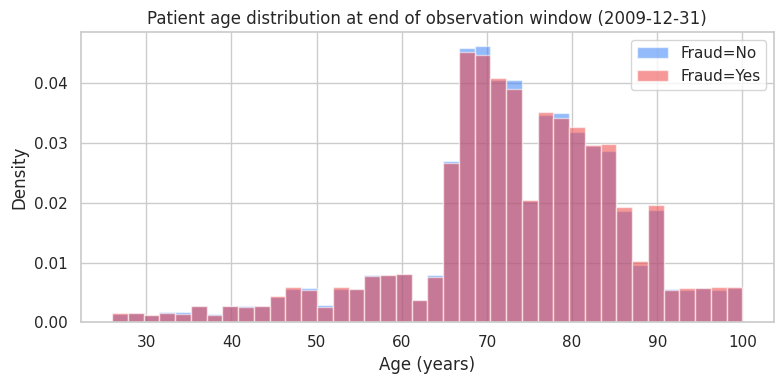

                     mean   50%   min    max
PotentialFraud                              
No              73.065583  74.0  26.0  100.0
Yes             73.221645  74.0  26.0  100.0


In [10]:
bene["DOB"] = pd.to_datetime(bene["DOB"])
bene["age"] = ((pd.Timestamp("2009-12-31") - bene["DOB"]).dt.days / 365.25).astype(int)
bene_lbl   = bene.merge(
    both[["BeneID", "PotentialFraud"]].drop_duplicates("BeneID"),
    on="BeneID", how="left")

fig, ax = plt.subplots(figsize=(8, 4))
for label, color in [("No", "#3b82f6"), ("Yes", "#ef4444")]:
    sub = bene_lbl[bene_lbl["PotentialFraud"] == label]["age"]
    ax.hist(sub, bins=40, alpha=0.55, label=f"Fraud={label}",
            color=color, density=True)
ax.set_title("Patient age distribution at end of observation window (2009-12-31)")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout(); plt.show()

print(bene_lbl.groupby("PotentialFraud")["age"].describe()[["mean","50%","min","max"]])

**Finding.** As expected for a Medicare cohort, ages cluster around the
65-and-over band; distributions for the two classes are visually identical
(mean ~73 in both). **Patient age is not a useful single feature** but
will still appear in the model for completeness (it interacts with chronic
condition counts).

## Chart 8 — Chronic condition burden

/tmp/ipykernel_1239707/2053126891.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=bene_lbl.dropna(subset=["PotentialFraud"]),


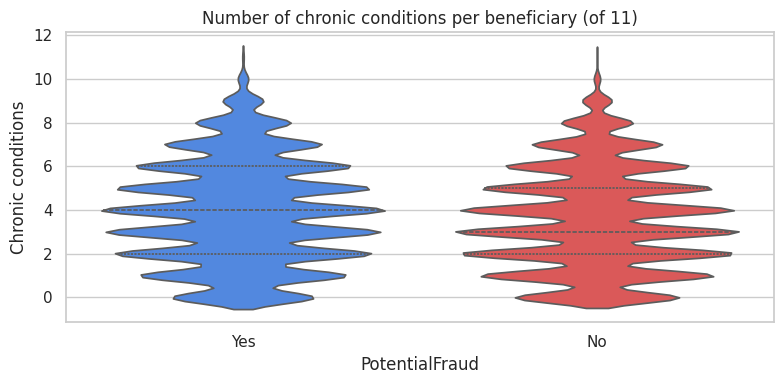

                    mean  50%   max
PotentialFraud                     
No              3.618168  3.0  11.0
Yes             3.917434  4.0  11.0


In [11]:
cc_cols = [c for c in bene.columns if c.startswith("ChronicCond_")]
# Dataset encoding: 1=Yes (has condition), 2=No.
bene["n_chronic"] = (bene[cc_cols] == 1).sum(axis=1)
bene_lbl["n_chronic"] = bene["n_chronic"].values

fig, ax = plt.subplots(figsize=(8, 4))
sns.violinplot(data=bene_lbl.dropna(subset=["PotentialFraud"]),
               x="PotentialFraud", y="n_chronic", ax=ax,
               palette=["#3b82f6", "#ef4444"], inner="quartile")
ax.set_title(f"Number of chronic conditions per beneficiary (of {len(cc_cols)})")
ax.set_ylabel("Chronic conditions")
plt.tight_layout(); plt.show()

print(bene_lbl.groupby("PotentialFraud")["n_chronic"].describe()[["mean","50%","max"]])

**Finding.** Fraud-provider beneficiaries carry slightly higher chronic
condition counts (mean 3.92 vs 3.62) — a weak but real signal that fraud
providers may be billing for higher-acuity patient panels. Useful as one
of several aggregate per-provider features rather than alone.

## Chart 9 — Claim volume over time

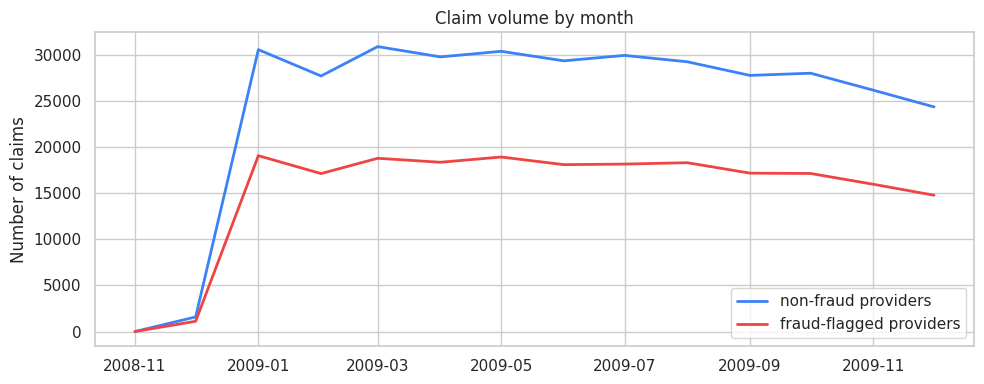

date range: 2008-11-27 to 2009-12-31


In [12]:
both["ClaimStartDt"] = pd.to_datetime(both["ClaimStartDt"])
monthly = (both.assign(month=both["ClaimStartDt"].dt.to_period("M"))
                .groupby(["month", "PotentialFraud"]).size()
                .unstack(fill_value=0))
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly.index, monthly["No"],  label="non-fraud providers",
        color="#3b82f6", lw=2)
ax.plot(monthly.index, monthly["Yes"], label="fraud-flagged providers",
        color="#ef4444", lw=2)
ax.set_title("Claim volume by month")
ax.set_ylabel("Number of claims")
ax.legend()
plt.tight_layout(); plt.show()

print("date range:", both["ClaimStartDt"].min().date(),
      "to", both["ClaimStartDt"].max().date())

**Finding.** Claim volume is stable month-over-month (~40k/mo non-fraud,
~25k/mo fraud) with a sharp ramp-up at the start (Nov–Dec 2008 are
partial) and a small dip at the end. The fraud share is roughly constant —
**no obvious seasonality to exploit**. Day-of-week and inter-arrival
features may still help and will be cheap to add.

## Chart 10 — Total per-provider reimbursement vs fraud

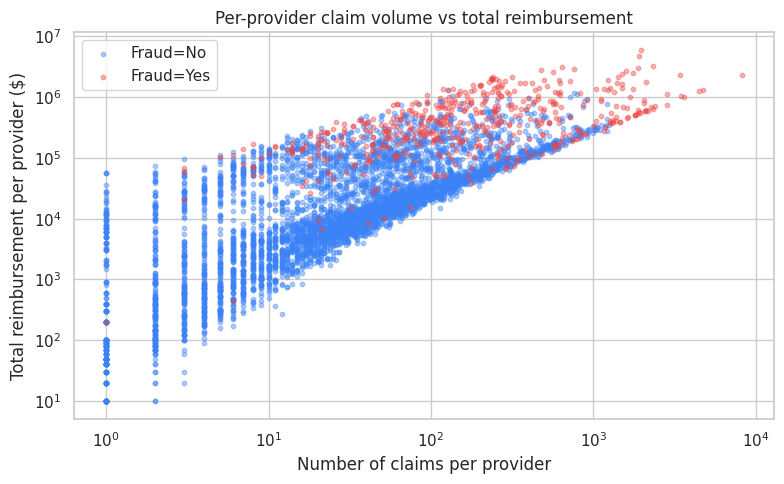

In [13]:
prov_agg = (both.groupby(["Provider", "PotentialFraud"])
                 .agg(n_claims=("InscClaimAmtReimbursed", "size"),
                      total_amt=("InscClaimAmtReimbursed", "sum"))
                 .reset_index())

fig, ax = plt.subplots(figsize=(8, 5))
for label, color in [("No", "#3b82f6"), ("Yes", "#ef4444")]:
    sub = prov_agg[prov_agg["PotentialFraud"] == label]
    ax.scatter(sub["n_claims"], sub["total_amt"], s=10, alpha=0.4,
               label=f"Fraud={label}", color=color)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Number of claims per provider")
ax.set_ylabel("Total reimbursement per provider ($)")
ax.set_title("Per-provider claim volume vs total reimbursement")
ax.legend()
plt.tight_layout(); plt.show()

**Finding.** Fraud-flagged providers (red) cluster decisively in the
upper-right of the plot — high claim count *and* high total
reimbursement. This is the visual confirmation that
**`(n_claims, total_reimbursed)` per provider is the dominant signal**.
A simple decision boundary in this 2-D space already separates a large
fraction of fraud providers.

## EDA Summary — implications for Day 2

| Signal                                        | Strength | How we will use it                                  |
|-----------------------------------------------|----------|------------------------------------------------------|
| Claims per provider                           | Very strong | Aggregate feature `n_claims_provider`               |
| Total / avg / std reimbursement per provider  | Very strong | Aggregate features `total_amt`, `mean_amt`, `std_amt` |
| State                                         | Strong   | Target-encode (high cardinality)                     |
| Inpatient/outpatient flag                     | Moderate | Boolean per-claim feature                            |
| Primary diagnosis code                        | Moderate | Target-encode top N, "other" bucket for the rest     |
| Chronic-condition count                       | Weak     | Per-beneficiary aggregate                            |
| Patient age                                   | Weak     | Per-beneficiary feature                              |
| Inpatient stay length                         | Weak     | Per-claim feature (inpatient only)                   |
| Temporal patterns                             | Weak     | Day-of-week, inter-arrival per provider              |

**Class imbalance:** ~9.35% positive. Use XGBoost `scale_pos_weight ≈ 10`,
report **PR-AUC** and **F1** as primary metrics, evaluate at multiple
thresholds.

**Modelling target:** Provider-level fraud, but scored per claim at inference
time (each incoming claim is decorated with the historical provider-level
aggregates as features).